# 06 Twitter vs Instagram

Les deux plateformes racontent-elles la même campagne ? Classement engagement Instagram, sentiment cross-platform, synchronie.

## 6.1 Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys
import warnings
warnings.filterwarnings('ignore')

_root = Path.cwd() if (Path.cwd() / "src").is_dir() else Path.cwd().parent
sys.path.insert(0, str(_root))
from src.utils import (
    COLORS, KEYS_ER, DATA_RAW, A1_DATA, FIG_DIR,
    swiss_style, setup_mpl, load_replies, _safe_read
)
setup_mpl()

replies = load_replies()
tweets = pd.read_csv(DATA_RAW / "tweets_twitter.csv")
posts_ig = pd.read_csv(DATA_RAW / 'posts_instagram.csv')
crossplat = _safe_read(A1_DATA / 'crossplatform_correlation.csv')

## 6.1 Volume par plateforme

Barplot groupé : n tweets vs n posts IG par candidat. Ratio IG/Twitter.

In [2]:
# Volume tweets vs IG par candidat
posts_ig["cand_norm"] = posts_ig["candidate"].replace("Gregoire", "Grégoire")
tw_cnt = tweets.groupby("candidate").size()
tw_cnt = tw_cnt.rename(index={"Gregoire": "Grégoire"})
tw_cnt = tw_cnt.reindex(KEYS_ER).fillna(0).astype(int)
ig_cnt = posts_ig.groupby("cand_norm").size().reindex(KEYS_ER).fillna(0).astype(int)
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(KEYS_ER))
w = 0.35
ax.bar(x - w/2, tw_cnt.values, w, label="Twitter", color="#1DA1F2")
ax.bar(x + w/2, ig_cnt.values, w, label="Instagram", color="#E4405F")
ax.set_xticks(x)
ax.set_xticklabels(KEYS_ER, rotation=45, ha="right")
ax.set_ylabel("Nombre de posts")
ax.legend()
swiss_style(ax, "6.1 Volume par plateforme", source="tweets, posts_ig")
fig.savefig(FIG_DIR / "06_volume_plateforme.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
ratio = (ig_cnt / tw_cnt.replace(0, np.nan)).fillna(0)
print("Ratio IG/Twitter:", ratio.to_string())

Ratio IG/Twitter: cand_norm
Knafo        0.715728
Brossat      0.455342
Chikirou     0.446084
Mariani      0.121375
Bournazel    0.337662
Grégoire     0.400688
Belliard     0.806452
Dati         0.212190


## 6.2 Classement par engagement Instagram

Engagement (likes + comments) par candidat sur IG. Comparer le rang IG au rang Twitter.

In [3]:
# Classement IG (likes + comments)
posts_ig["eng"] = posts_ig["likes"].fillna(0) + posts_ig.get("comments", pd.Series(0)).fillna(0)
ig_eng = posts_ig.groupby("cand_norm")["eng"].sum().sort_values(ascending=True)
tw_cnt_norm = tweets.groupby("candidate").size(); tw_cnt_norm.index = tw_cnt_norm.index.map(lambda x: "Grégoire" if x=="Gregoire" else x)
tw_rank = tw_cnt_norm.groupby(level=0).sum().rank(ascending=False)
ig_rank = ig_eng.rank(ascending=False)
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(range(len(ig_eng)), ig_eng.values / 1e3, color=[COLORS.get(c, "#888") for c in ig_eng.index])
ax.set_yticks(range(len(ig_eng)))
ax.set_xlabel("Engagement (k)")
ax.set_yticklabels([f"{c} (Rang IG:{int(ig_rank[c])} TW:{int(tw_rank.get(c, 0))})" for c in ig_eng.index])
swiss_style(ax, "6.2 Engagement IG (k)", source="posts_instagram")
fig.savefig(FIG_DIR / "06_classement_ig.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

## 6.2 Sentiment cross-platform (Twitter vs Instagram)

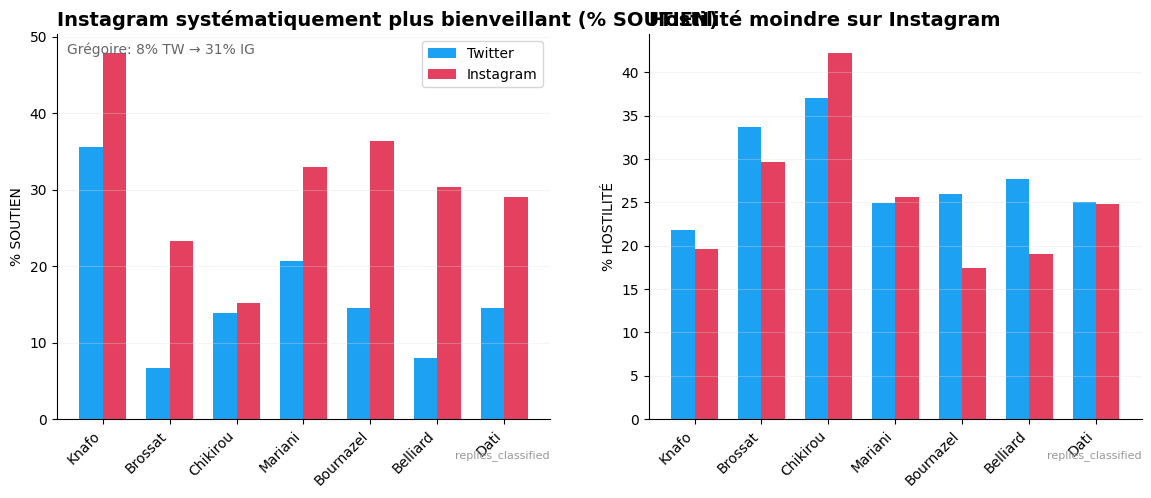

In [ ]:
tw = replies[replies['platform'] == 'twitter'].groupby('candidate')['sentiment'].value_counts(normalize=True).unstack(fill_value=0) * 100
ig = replies[replies['platform'] == 'instagram'].groupby('candidate')['sentiment'].value_counts(normalize=True).unstack(fill_value=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sout_tw = tw['SOUTIEN'] if 'SOUTIEN' in tw.columns else tw.get('SOUTIEN', 0)
sout_ig = ig['SOUTIEN'] if 'SOUTIEN' in ig.columns else ig.get('SOUTIEN', 0)
order = [c for c in KEYS_ER if c in tw.index]
x = np.arange(len(order))
w = 0.35
axes[0].bar(x - w/2, [sout_tw.get(c, 0) for c in order], w, label='Twitter', color='#1DA1F2')
axes[0].bar(x + w/2, [sout_ig.get(c, 0) for c in order], w, label='Instagram', color='#E4405F')
axes[0].set_xticks(x)
axes[0].set_xticklabels(order, rotation=45, ha='right')
axes[0].set_ylabel('% SOUTIEN')
axes[0].legend()
swiss_style(axes[0], 'Instagram systématiquement plus bienveillant (% SOUTIEN)', 'Grégoire: 8% TW → 31% IG', 'replies_classified')

host_tw = tw['HOSTILITE'] if 'HOSTILITE' in tw.columns else pd.Series(dtype=float)
host_ig = ig['HOSTILITE'] if 'HOSTILITE' in ig.columns else pd.Series(dtype=float)
axes[1].bar(x - w/2, [host_tw.get(c, 0) for c in order], w, color='#1DA1F2')
axes[1].bar(x + w/2, [host_ig.get(c, 0) for c in order], w, color='#E4405F')
axes[1].set_xticks(x)
axes[1].set_xticklabels(order, rotation=45, ha='right')
axes[1].set_ylabel('% HOSTILITÉ')
swiss_style(axes[1], 'Hostilité moindre sur Instagram', '', 'replies_classified')
fig.savefig(FIG_DIR / '06_sentiment_crossplatform.png', dpi=300, bbox_inches='tight', pad_inches=0.3, facecolor='white')
plt.show()

## 6.3 Synchronie (Spearman Twitter-Instagram)

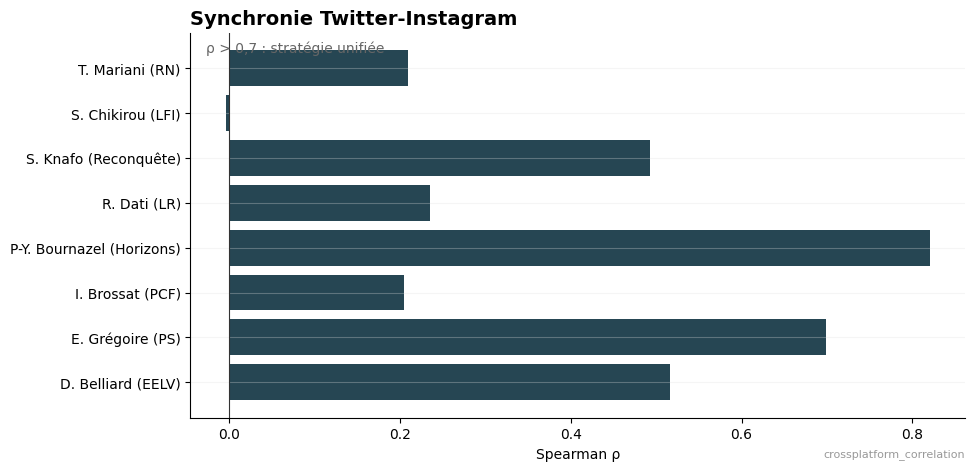

In [5]:
if crossplat is not None:
    tw_ig = crossplat[(crossplat['platform_1'] == 'twitter') & (crossplat['platform_2'] == 'instagram')]
    fig, ax = plt.subplots(figsize=(10, 5))
    labs = tw_ig['candidate_label'].str.replace(r'\. \w+ \(.*\)', '', regex=True).str.strip()
    colors = [COLORS.get(l.split()[0] if l else '', '#333') for l in labs]
    ax.barh(range(len(tw_ig)), tw_ig['spearman_rho'], color='#264653')
    ax.set_yticks(range(len(tw_ig)))
    ax.set_yticklabels(tw_ig['candidate_label'])
    ax.axvline(0, color='#333', lw=0.8)
    swiss_style(ax, 'Synchronie Twitter-Instagram', 'ρ > 0,7 : stratégie unifiée', 'crossplatform_correlation')
    ax.set_xlabel('Spearman ρ')
    fig.savefig(FIG_DIR / '06_synchronie.png', dpi=300, bbox_inches='tight', pad_inches=0.3, facecolor='white')
    plt.show()

## 6.4 Distribution détaillée par plateforme

Stacked barplot : candidat × plateforme × proportion des 4 classes de sentiment.

In [6]:
# Stacked candidat x plateforme x 4 classes (twitter + instagram)
rep_norm = replies.copy()
rep_norm["sent_norm"] = rep_norm["sentiment"].replace({"HOSTILITE":"HOSTILITÉ"})
rep_norm["cand_norm"] = rep_norm["candidate"].replace("Gregoire","Grégoire")
dist = rep_norm.groupby(["cand_norm","platform"])["sent_norm"].value_counts(normalize=True).unstack(fill_value=0) * 100
cols = [c for c in ["SOUTIEN","CRITIQUE","HOSTILITÉ","IRONIE"] if c in dist.columns or (c=="HOSTILITÉ" and "HOSTILITE" in dist.columns)]
if "HOSTILITE" in dist.columns and "HOSTILITÉ" not in dist.columns: dist["HOSTILITÉ"] = dist["HOSTILITE"]
cols = [c for c in ["SOUTIEN","CRITIQUE","HOSTILITÉ","IRONIE"] if c in dist.columns]
fig, ax = plt.subplots(figsize=(10, 5))
agg = dist.groupby(level=0).mean().reindex(KEYS_ER).fillna(0)
bottom = np.zeros(len(KEYS_ER))
for col in cols:
    ax.bar(range(len(KEYS_ER)), agg[col].values, bottom=bottom, label=col, color={"SOUTIEN":"#2D6A4F","CRITIQUE":"#F4A261","HOSTILITÉ":"#E63946","IRONIE":"#6D4C41"}.get(col,"#888"))
    bottom += agg[col].values
ax.set_xticks(range(len(KEYS_ER)))
ax.set_xticklabels(KEYS_ER, rotation=45, ha="right")
ax.legend()
swiss_style(ax, "6.4 Répartition sentiment par candidat", source="replies")
fig.savefig(FIG_DIR / "06_distribution_plateforme.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

## 6.6 Thématiques IG vs Twitter

TF-IDF sur posts IG vs tweets. Barplot miroir : mots distinctifs de chaque plateforme.

In [7]:
# TF-IDF IG vs Twitter - barplot miroir
from sklearn.feature_extraction.text import TfidfVectorizer
import re
STOP = set("le la les un une des du de ce et ou mais donc car".split())
def clean(t):
    if pd.isna(t): return ""
    s = re.sub(r"[^a-zàâäéèêëïîôùûüç\\s]"," ", str(t).lower())
    return " ".join(w for w in s.split() if len(w)>1 and w not in STOP)
tw_txt = " ".join(tweets["text"].fillna("").apply(clean))
ig_txt = " ".join(posts_ig["text"].fillna("").apply(clean))
vec = TfidfVectorizer(max_features=3000)
mat = vec.fit_transform([tw_txt, ig_txt])
names = vec.get_feature_names_out()
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for i, (ax, label, color) in enumerate(zip(axes, ["Twitter", "Instagram"], ["#1DA1F2", "#E4405F"])):
    row = mat[i].toarray().flatten()
    idx = np.argsort(row)[-12:][::-1]
    mots = [names[j] for j in idx if row[j] > 0][:10]
    vals = [row[j] for j in idx if row[j] > 0][:10]
    ax.barh(range(len(mots)), vals, color=color, alpha=0.8)
    ax.set_yticks(range(len(mots)))
    ax.set_yticklabels(mots, fontsize=9)
    swiss_style(ax, f"6.6 {label}", source="")
fig.suptitle("Mots distinctifs par plateforme", fontsize=12, fontweight="bold", x=0, y=1.02, ha="left")
fig.savefig(FIG_DIR / "06_thematiques_ig_tw.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

## 6.7 Longueur et style

Boxplot longueur des posts IG vs tweets par candidat.

In [8]:
# Boxplot longueur IG vs tweets par candidat
tweets["len"] = tweets["text"].fillna("").str.len()
posts_ig["len"] = posts_ig["text"].fillna("").str.len()
tw_len = tweets.groupby("candidate")["len"].apply(list)
ig_len = posts_ig.groupby("cand_norm")["len"].apply(list)
fig, ax = plt.subplots(figsize=(10, 5))
tweets["cand_norm"] = tweets["candidate"].replace("Gregoire","Grégoire")
data_tw = [tweets[tweets["cand_norm"]==c]["len"].clip(upper=500) for c in KEYS_ER]
data_ig = [posts_ig[posts_ig["cand_norm"]==c]["len"].clip(upper=500) for c in KEYS_ER]
bp1 = ax.boxplot(data_tw, positions=np.arange(len(KEYS_ER))-0.2, widths=0.35, patch_artist=True, labels=KEYS_ER)
bp2 = ax.boxplot(data_ig, positions=np.arange(len(KEYS_ER))+0.2, widths=0.35, patch_artist=True)
for p in bp1["boxes"]: p.set_facecolor("#1DA1F2"); p.set_alpha(0.7)
for p in bp2["boxes"]: p.set_facecolor("#E4405F"); p.set_alpha(0.7)
ax.set_xticks(range(len(KEYS_ER)))
ax.set_xticklabels(KEYS_ER, rotation=45, ha="right")
ax.set_ylabel("Longueur (caractères)")
ax.legend([bp1["boxes"][0], bp2["boxes"][0]], ["Twitter", "Instagram"])
swiss_style(ax, "6.7 Longueur des posts par plateforme", source="tweets, posts_ig")
fig.savefig(FIG_DIR / "06_longueur_style.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

## 6.4 — Synthèse

Instagram est systématiquement plus bienveillant (ex. Grégoire : 8% soutien Twitter → 31% Instagram). La synchronie varie : Bournazel et Grégoire (ρ > 0,7) adoptent une stratégie unifiée ; Chikirou reste indépendante.